# Oppgave 2: Transferfunksjon for RLC-krets

Figuren nedenfor viser en RLC-krets. Kretsen påtrykkes en variabel spenning med spenningskilden $v_0(t)$, og vi skal måle spenningen over kondensatoren $v_C(t)$.
![](Figurer/RLC-krets.png)

RLC-kretser slik som dette brukes blant annet til å filtrere lydsignal, og separere ut f.eks. bass eller diskant.

* Forholdet mellom spenningen $v_0(t)$ fra spenningskilden og kondensatorspenningen $v_C(t)$ kan beskrives med en andreordens differensialligning:

$$ v_0(t) = LC \cdot \frac{d^2 v_C(t)}{dt^2} + RC\cdot \frac{d v_C(t)}{dt} + v_C(t)$$

* En svært nyttig egenskap for laplacetransformen er at derivasjon i tidsdomenet tilsvarer multiplikasjon med variabelen $s$ i lapalce-domenet:
$$\mathcal{L}\left(\frac{x(t)}{dt} \right) = s\cdot X(s), \ \ \ \text{ der } X(s) = \mathcal{L}(x(t) $$
Konsekvensen av dette er at vi ved hjelp av laplacetransformasjon kan omforme en differensialligning (vanskelig å løse) til en algebraisk ligning (forholdsvis enkel å løse).

***
### Oppgave a)

Vi definerer transferfunksjonen $H(s)$ til RLC-kretsen som $H(s) = \frac{V_C(s)}{V_0(s)}$. Finn uttrykket for $H(s)$ 


#### Løsning:
$$
\begin{align}
\mathcal{L}\left(v_0(t)\right) &= \mathcal{L}\left(LC \cdot \frac{d^2 v_C(t)}{dt^2} + RC\cdot \frac{d v_C(t)}{dt} + v_C(t)\right) \\
V_0(s) &= LC\cdot s^2 \cdot V_C(s) + RC \cdot s \cdot V_C(s) + V_C(s) \\
V_0(s) &= V_C(s)\left(LC\cdot s^2 + RC \cdot s + 1\right) \\
& \\
H(s) = \frac{V_C(s)}{V_0(s)} &= \frac{1}{LC\cdot s^2 + RC \cdot s + 1} \\
&= \frac{\frac{1}{LC}}{s^2 + \frac{R}{L} \cdot s + \frac{1}{LC}} 
\end{align}
$$


***
Videre i oppgaven går vi ut ifra at komponentene i kretsen har følgende verdier:

* $R = 10 \ \Omega$
* $L = 5 \ m H$
* $C = 50 \ \mu F$

***
### Oppgave b)

Transferfunksjoner for RLC-kretser skrives ofte som funksjon av *dempingsrate* $\zeta$, og *naturlig frekvens* $\omega_0$ som følger:

$$ H(s) = \frac{\omega_0^2}{s^2 + 2\zeta \omega_0 s + \omega_0^2}$$

hva blir dempingsraten $\zeta$ og den naturlige frekvensen $\omega_0$ til kretsen? Er systemet underdempet, kritisk dempet eller overdempet?

#### Løsning:
$$
\begin{align}
\omega_0 &= \sqrt{\frac{1}{LC}} \\
&= \frac{1}{5\cdot 10^{-5} \cdot 5 \cdot 10^{-3}} \\
&= 2000\\
& \\
\zeta &= \frac{R}{L} \cdot \frac{1}{2\omega_0}\\
&= \frac{10}{5\cdot 10^{-3}} \cdot \frac{1}{2 \cdot 2000} \\
&= 2000 \cdot \frac{1}{4000} \\
&= 0.5
\end{align}
$$

Dempingsraten $\zeta < 1$. Dette betyr at systemet er underdempet.
***

## Transferfunksjoner i Python

`scipy`-modulen til Python inneholder en egen funksjon [`scipy.signal.TransferFunction(num, den)`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.TransferFunction.html#scipy.signal.TransferFunction) for å lage egne transferfunksjon-objekter vi kan bruke til å *simulere* elektriske kretser. For at denne skal kunne etterligne riktig transferfunksjon, må vi gi den to arrays med koeffisientene til både telleren og nevneren i transferfunksjonen $H(s)$.

#### Eksempel:

* Transferfunksjon:
$$H(s) = \frac{s + 2}{s^2 + 6s + 9} = \frac{1\cdot s + 2}{1\cdot s^2 + 6\cdot s + 9} $$

* Konstruksjon av transferfunksjon i Python:
```Python
import scipy.signal as sig
numerator = [1, 2]
denominator = [1, 6, 9]
system = sig.TransferFunction(numerator, denominator)
```

***
### Oppgave c)
Bruk funksjonen [`step`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.step.html) i modulen `scipy.signal` til å regne ut sprangresponsen til RLC-kretsen, og bruk matplotlib til å tegne en graf av den naturlige responsen. Stemmer formen på sprangresponsen med dempingsraten du fant i deloppgave ***b)***?
***

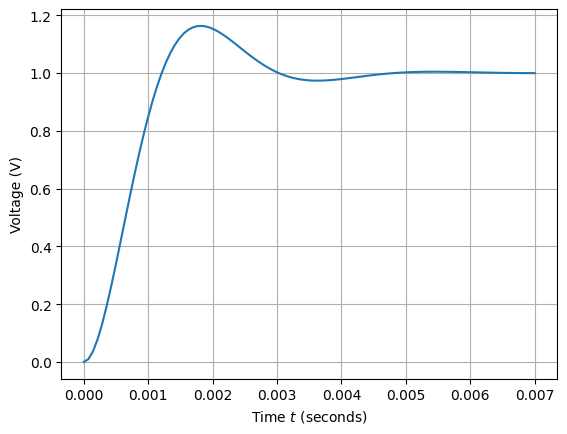

In [5]:
# LØSNING!
import scipy.signal as sig
import numpy as np
import matplotlib.pyplot as plt


R = 10 # Ohm
L = 5e-3 # Henry
C = 5e-5 # Farad

omega = np.sqrt(1/(L*C))
zeta = (R/L)/(2*omega)

numerator = [1/(L*C)]
denominator = [1, R/L, 1/(L*C)]
system = sig.TransferFunction(numerator, denominator)

t, V_out = sig.step(system)

plt.plot(t, V_out)
plt.xlabel("Time $t$ (seconds)")
plt.ylabel("Voltage (V)")
plt.grid(True)

# Sprangresponsen inneholder tegn på oscillasjoner, noe som er indikativt av et underdempet system